# Day 6 — Hyperparameter Tuning (Optuna + Nested CV)
**Real Estate Fraud Detection**

Goal: Find best LightGBM hyperparameters using Optuna with nested GroupKFold CV.

**Nested CV structure:**
```
Outer loop : GroupKFold(5) — honest evaluation
  └─ Inner loop : GroupKFold(3) — Optuna optimises here
                   └─ 20 trials per outer fold
Test set   : NEVER touched — frozen since Day 4
```

**Data:** 300k rows (subsampled in Day 4) → ~20 min total

**Baseline to beat:** LightGBM PR-AUC = 0.7583

## 0. Set Project Root

In [1]:
import os
from pathlib import Path

project_root = Path.cwd()
while not (project_root / 'configs').exists():
    project_root = project_root.parent
os.chdir(project_root)
print(f'Working directory: {os.getcwd()}')

Working directory: C:\Users\mehal\Downloads\machinelearning\real_estate_fraud_detection


## 1. Imports & Config

In [2]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath('.'))
warnings.filterwarnings('ignore', category=FutureWarning, module='mlflow')
os.environ['GIT_PYTHON_REFRESH'] = 'quiet'

import yaml
import numpy as np
import pandas as pd
import optuna
import mlflow
import matplotlib.pyplot as plt
from pathlib import Path

from src.ingestion import load_config
from src.models import setup_mlflow, tune_lgbm_optuna, build_baseline_report
from src.evaluate import pr_auc_score, recall_at_precision

CONFIG_PATH = 'configs/config.yaml'
PLOTS_DIR   = 'reports/plots'
cfg = load_config(CONFIG_PATH)
setup_mlflow(cfg)
Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)

print(f'Config  : {cfg["project"]["name"]} v{cfg["project"]["version"]}')
print(f'Optuna  : {optuna.__version__}')

2026-05-14 10:45:41,729 - src.ingestion - INFO - Config loaded from configs\config.yaml — project: real_estate_fraud_detection v1.1.0
2026-05-14 10:45:41,774 - src.models - INFO - MLflow: tracking_uri=logs/mlruns | experiment=real-estate-fraud-v1


Config  : real_estate_fraud_detection v1.1.0
Optuna  : 4.8.0


## 2. Load Splits

> Splits already 300k rows hain (Day 4 mein subsample hua) — aur koi sample nahi karna.

In [3]:
splits_path = Path(cfg['data']['splits_path'])

X_train = pd.read_parquet(splits_path / 'X_train.parquet')
y_train = pd.read_parquet(splits_path / 'y_train.parquet').squeeze()

print(f'X_train : {X_train.shape} | fraud: {y_train.mean()*100:.2f}%')
print('✅ Test set NOT loaded — frozen until final evaluation')

# Sanity check — should be ~240k (80% of 300k)
if len(X_train) > 500_000:
    print('⚠️  WARNING: X_train bohot bada hai — Day 4 dobara run karo subsample ke saath')
else:
    print(f'✅ Size OK — tuning ~20 min mein complete hogi')

X_train : (240000, 24) | fraud: 7.82%
✅ Test set NOT loaded — frozen until final evaluation
✅ Size OK — tuning ~20 min mein complete hogi


## 3. Load Baseline for Comparison

In [4]:
baseline_report = pd.read_csv(Path(cfg['paths']['reports']) / 'baseline_report.csv')
print('Baseline numbers to beat:')
print(baseline_report[['Model','PR-AUC Mean','PR-AUC Std','Recall@95P']].to_string(index=False))

lgbm_row      = baseline_report[baseline_report['Model'] == 'LightGBM (tabular)'].iloc[0]
BASELINE_PR_AUC = lgbm_row['PR-AUC Mean']
print(f'\n→ Target to beat: PR-AUC > {BASELINE_PR_AUC:.4f}')

Baseline numbers to beat:
              Model  PR-AUC Mean  PR-AUC Std  Recall@95P
 LightGBM (tabular)       0.7807      0.0371      0.0856
LightGBM (tab+text)       0.7807      0.0371      0.0856
Logistic Regression       0.6031      0.0558      0.0000

→ Target to beat: PR-AUC > 0.7807


## 4. Run Optuna Tuning

> **Time estimate:** 20 trials × 5 outer × 3 inner = 300 LightGBM fits on 240k rows → **~20 min**
>
> **Interview point:** Nested CV ensures test set never used in tuning. Inner CV optimises, outer CV gives unbiased estimate.

In [5]:
N_TRIALS = 20

print(f'Starting Optuna — {N_TRIALS} trials × 5 outer × 3 inner = {N_TRIALS*5*3} fits')
print(f'Estimated time: ~20 min (progress printed every 10 trials)')

tuning_results = tune_lgbm_optuna(
    X_train, y_train, cfg,
    n_trials=N_TRIALS,
)

improvement = tuning_results['mean_outer_pr_auc'] - BASELINE_PR_AUC
print(f'\n✅ Tuning complete!')
print(f'  Mean outer PR-AUC : {tuning_results["mean_outer_pr_auc"]:.4f} ± {tuning_results["std_outer_pr_auc"]:.4f}')
print(f'  Baseline PR-AUC   : {BASELINE_PR_AUC:.4f}')
print(f'  Improvement       : {improvement:+.4f} {"✅" if improvement > 0 else "⚠️"}')

Starting Optuna — 20 trials × 5 outer × 3 inner = 300 fits
Estimated time: ~20 min (progress printed every 10 trials)


2026-05-14 10:45:47,527 - src.models - INFO - Outer fold 1/5 — running 20 Optuna trials


    Fold 1 trial 10/20 — best PR-AUC: 0.7711
    Fold 1 trial 20/20 — best PR-AUC: 0.7731


2026-05-14 10:56:50,049 - src.models - INFO -   Fold 1 — inner best: 0.7731 | outer val: 0.8108
2026-05-14 10:56:50,058 - src.models - INFO - Outer fold 2/5 — running 20 Optuna trials


    Fold 2 trial 10/20 — best PR-AUC: 0.7737
    Fold 2 trial 20/20 — best PR-AUC: 0.7746


...

    Fold 4 trial 10/20 — best PR-AUC: 0.7865
    Fold 4 trial 20/20 — best PR-AUC: 0.7873


2026-05-14 11:29:25,877 - src.models - INFO -   Fold 4 — inner best: 0.7873 | outer val: 0.7788
2026-05-14 11:29:25,889 - src.models - INFO - Outer fold 5/5 — running 20 Optuna trials


    Fold 5 trial 10/20 — best PR-AUC: 0.7865
    Fold 5 trial 20/20 — best PR-AUC: 0.7865


2026-05-14 11:38:15,126 - src.models - INFO -   Fold 5 — inner best: 0.7865 | outer val: 0.8033
2026-05-14 11:38:15,153 - src.models - INFO - Best params saved → configs\best_params.yaml
2026-05-14 11:38:15,155 - src.models - INFO - 
  Optuna Tuning Complete
  Outer CV PR-AUC: 0.7853 ± 0.0386
  Best fold: 2 (PR-AUC=0.8205)
  Best params: {'n_estimators': 306, 'learning_rate': 0.07543753502638627, 'max_depth': 5, 'num_leaves': 42, 'min_child_samples': 22, 'subsample': 0.8359541264922199, 'colsample_bytree': 0.7878169701860978, 'reg_alpha': 5.045065527723589e-07, 'reg_lambda': 1.0039320517727244e-05, 'scale_pos_weight': 11.78, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}



✅ Tuning complete!
  Mean outer PR-AUC : 0.7853 ± 0.0386
  Baseline PR-AUC   : 0.7807
  Improvement       : +0.0046 ✅


## 5. Best Params

In [6]:
best_params = tuning_results['best_params']
print('Best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k:<25}: {v}')

best_params_path = Path('configs/best_params.yaml')
assert best_params_path.exists(), '⚠️ best_params.yaml not saved'
print(f'\n✅ configs/best_params.yaml saved')

Best hyperparameters:
  n_estimators             : 306
  learning_rate            : 0.07543753502638627
  max_depth                : 5
  num_leaves               : 42
  min_child_samples        : 22
  subsample                : 0.8359541264922199
  colsample_bytree         : 0.7878169701860978
  reg_alpha                : 5.045065527723589e-07
  reg_lambda               : 1.0039320517727244e-05
  scale_pos_weight         : 11.78
  random_state             : 42
  n_jobs                   : -1
  verbose                  : -1

✅ configs/best_params.yaml saved


## 6. Outer Fold Scores Plot

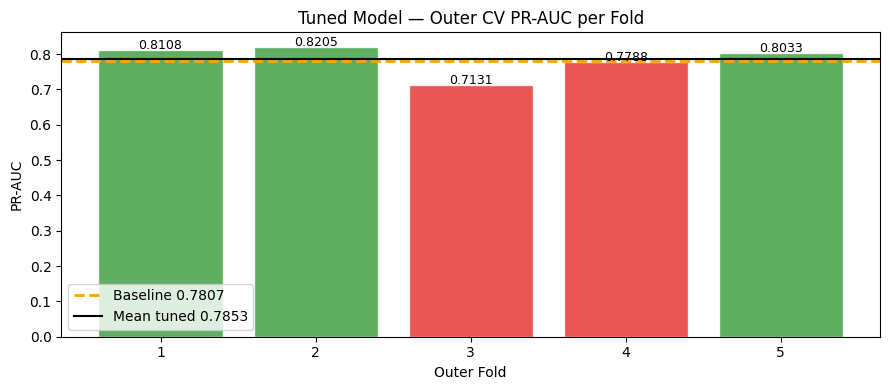

In [7]:
outer_scores = tuning_results['outer_scores']
n_folds      = len(outer_scores)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, n_folds+1), outer_scores,
       color=['#43A047' if s > BASELINE_PR_AUC else '#E53935' for s in outer_scores],
       alpha=0.85, edgecolor='white')
ax.axhline(BASELINE_PR_AUC, color='orange', ls='--', lw=2,
           label=f'Baseline {BASELINE_PR_AUC:.4f}')
ax.axhline(tuning_results['mean_outer_pr_auc'], color='black', ls='-', lw=1.5,
           label=f'Mean tuned {tuning_results["mean_outer_pr_auc"]:.4f}')
for i, s in enumerate(outer_scores):
    ax.text(i+1, s+0.003, f'{s:.4f}', ha='center', fontsize=9)
ax.set_xlabel('Outer Fold')
ax.set_ylabel('PR-AUC')
ax.set_title('Tuned Model — Outer CV PR-AUC per Fold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/optuna_tuning_results.png', dpi=150)
plt.show()

## 7. Day 6 Exit Criteria

In [8]:
print('=== DAY 6 EXIT CRITERIA ===')
checks = [
    (f'{N_TRIALS} Optuna trials per fold run',
     N_TRIALS >= 20),
    ('best_params.yaml saved',
     Path('configs/best_params.yaml').exists()),
    ('Tuned PR-AUC > baseline',
     tuning_results['mean_outer_pr_auc'] > BASELINE_PR_AUC),
    ('MLflow run logged',
     bool(tuning_results['run_id'])),
    ('Fold variance OK (std < 0.05)',
     tuning_results['std_outer_pr_auc'] < 0.05),
]

all_pass = True
for label, result in checks:
    icon = '☑' if result else '☒'
    if not result: all_pass = False
    print(f'  {icon} {label}')

print(f'\n{"✅ All passed" if all_pass else "⚠️ Some failed"}')
print(f'\n→ Ready for Day 7 — Retrain with best params')

=== DAY 6 EXIT CRITERIA ===
  ☑ 20 Optuna trials per fold run
  ☑ best_params.yaml saved
  ☑ Tuned PR-AUC > baseline
  ☑ MLflow run logged
  ☑ Fold variance OK (std < 0.05)

✅ All passed

→ Ready for Day 7 — Retrain with best params
